# **Dinámica de largo plazo del agua superficial con JRC Global Surface Water**

## Caso de estudio: Lago Poopó, Bolivia

---

En este ejercicio utilizaremos productos globales de observación de la Tierra para analizar los cambios de largo plazo en la extensión y permanencia del agua superficial.

El caso de estudio será el **Lago Poopó**, localizado en el Altiplano boliviano, un sistema lacustre altamente dinámico que ha experimentado importantes procesos de expansión y contracción durante las últimas décadas.

Utilizaremos el producto **JRC Global Surface Water (GSW)** disponible en **Google Earth Engine**, junto con Python y la librería `geemap`.

La pregunta principal que guiará el ejercicio será:

***¿Cómo ha cambiado la extensión y la permanencia del agua superficial en el Lago Poopó entre 1984 y 2021?***

# 0. Introducción

Los cuerpos de agua presentan una elevada variabilidad espacial y temporal.

Lagos, embalses, humedales y planicies de inundación pueden cambiar como respuesta a múltiples factores, entre ellos:

- variabilidad climática
- sequías e inundaciones
- regulación de ríos
- extracción de agua
- cambios de uso del suelo
- sedimentación
- modificaciones geomorfológicas

El monitoreo convencional de estas dinámicas puede ser difícil debido a la extensión de los territorios, la disponibilidad limitada de estaciones y la ausencia de registros históricos continuos.

Las observaciones satelitales permiten reconstruir varias décadas de cambios. En este ejercicio utilizaremos el **JRC Global Surface Water**, un producto global derivado principalmente de observaciones Landsat.

---

## ¿Por qué el Lago Poopó?

El Lago Poopó constituye un caso interesante para estudiar cambios de largo plazo debido a la gran variabilidad histórica de su superficie.

Esta dinámica permite explorar varias preguntas:

*-¿Dónde ha estado presente históricamente el agua?*

*-¿Qué sectores del lago han sido más persistentes?*

*-¿Cuánta superficie de agua existía cada año?*

*-¿Qué proporción correspondía a agua permanente o estacional?*

*-¿Cuáles fueron los años de mayor y menor extensión?*

*-¿Dónde se concentraron las pérdidas o ganancias de agua?*

*-¿Qué ocurrió durante el fuerte evento de contracción observado alrededor de 2015–2016?*

# 1. Objetivos del ejercicio

## Objetivo general

Analizar la dinámica espacio-temporal de largo plazo del agua superficial en el Lago Poopó utilizando el producto JRC Global Surface Water y Google Earth Engine.

## Al finalizar este ejercicio podrás:

1. Acceder a productos globales de agua superficial desde Google Earth Engine.

2. Interpretar las principales variables del producto JRC Global Surface Water.

3. Visualizar patrones espaciales de:
   - ocurrencia;
   - estacionalidad;
   - recurrencia del agua.

4. Explorar la clasificación anual de agua superficial.

5. Calcular la superficie anual del Lago Poopó entre 1984 y 2021.

6. Diferenciar entre:
   - agua permanente;
   - agua estacional.

7. Identificar:
   - años de máxima extensión;
   - años de mínima extensión;
   - principales contracciones;
   - principales recuperaciones.

8. Analizar espacialmente los cambios de largo plazo.

9. Examinar en mayor detalle la dinámica mensual durante 2013–2017.

10. Reconocer algunas limitaciones asociadas con el uso de productos globales de agua superficial.

# 2. JRC Global Surface Water

El producto **JRC Global Surface Water (GSW)** fue desarrollado por el Joint Research Centre (JRC) de la Comisión Europea en colaboración con Google.

El producto utiliza millones de observaciones de los satélites Landsat para identificar la presencia o ausencia de agua superficial.

## Características principales

| Característica | Descripción |
|---|---|
| Cobertura espacial | Global |
| Resolución espacial | 30 m |
| Período | 1984–2021 |
| Sensores | Landsat 5, Landsat 7 y Landsat 8 |
| Plataforma de análisis | Google Earth Engine |

Utilizaremos tres productos complementarios:

### 1. Global Surface Water Mapping Layers

`JRC/GSW1_4/GlobalSurfaceWater`

Resume diferentes características de la dinámica del agua durante todo el período de observación.

Contiene las bandas:

| Banda | Significado |
|---|---|
| `occurrence` | Frecuencia de presencia de agua (%) |
| `change_abs` | Cambio en ocurrencia entre dos períodos |
| `change_norm` | Cambio normalizado |
| `seasonality` | Número de meses con presencia de agua |
| `recurrence` | Frecuencia con la que el agua retorna entre años |
| `transition` | Tipo de transición observada |
| `max_extent` | Lugares donde alguna vez se detectó agua |

---

### 2. Yearly Water Classification History

`JRC/GSW1_4/YearlyHistory`

Contiene una imagen para cada año.

Cada píxel se clasifica como:

| Valor | Clase |
|---:|---|
| 0 | Sin datos |
| 1 | No agua |
| 2 | Agua estacional |
| 3 | Agua permanente |

Este producto será utilizado para reconstruir la serie temporal anual del Lago Poopó.

---

### 3. Monthly Water History

`JRC/GSW1_4/MonthlyHistory`

Contiene la historia mensual de detección de agua.

Cada píxel puede tomar los valores:

| Valor | Clase |
|---:|---|
| 0 | Sin datos |
| 1 | No agua |
| 2 | Agua |

Utilizaremos este producto al final del ejercicio para estudiar con mayor detalle el período 2013–2017.

## Antes de continuar

Es importante distinguir tres conceptos que utilizaremos durante el ejercicio.

### Ocurrencia

Indica con qué frecuencia se detectó agua en un píxel durante el período de observación.

Una ocurrencia alta indica una presencia de agua muy persistente.

---

### Estacionalidad

Representa el número de meses con presencia de agua.

Permite diferenciar sectores con mayor o menor persistencia intra-anual.

---

### Recurrencia

Indica con qué frecuencia el agua retorna de un año a otro.

Por ejemplo, una zona puede inundarse solamente algunos meses del año pero hacerlo de manera recurrente durante muchos años.

---

### Pregunta

Antes de observar los datos:

*¿Qué patrón esperarías encontrar en el Lago Poopó?*

*¿Esperarías que la mayor parte del lago presente ocurrencias cercanas al 100 %?*

*¿O esperarías encontrar grandes superficies con ocurrencias intermedias?*

# 3. Preparación del entorno

Utilizaremos:

- `ee`: API de Python de Google Earth Engine;
- `geemap`: mapas interactivos;
- `pandas`: manejo de tablas y series temporales;
- `numpy`: operaciones numéricas;
- `matplotlib`: visualización de resultados.

In [1]:
# ============================================================
# Importar librerías
# ============================================================

import ee
import geemap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from IPython.display import display
from google.colab import auth

print("Librerías importadas correctamente.")

Librerías importadas correctamente.


## Autenticación en Google Earth Engine

Antes de utilizar Google Earth Engine (GEE) debemos autorizar el acceso desde
el notebook.

Ingresa al editor de código de GEE:
https://code.earthengine.google.com/

**En la parte superior derecha, has clic en el perfil de usuario y abre Project info (información del proyecto) y copia el nombre del proyecto. Reemplaza el nombre del proyecto en la siguiente celda de este script en el campo "PROJECT_ID"**

En este ejercicio utilizaremos el modo de autenticación `notebook`.

Luego ejecuta la siguiente celda:

1. aparecerá un enlace de autorización;
2. abre el enlace en una nueva pestaña;
3. inicia sesión con tu cuenta de Google;
4. autoriza el acceso solicitado;
5. copia el código de verificación generado;
6. regresa al notebook y pega el código cuando sea solicitado.

Una vez completada la autenticación, Earth Engine almacenará temporalmente
las credenciales para esta sesión.

In [4]:
# ============================================================
# Autenticación e inicialización de Google Earth Engine
# ============================================================

PROJECT_ID = "ee-sebastianpalominoangel"

# Autenticación manual mediante enlace y código
ee.Authenticate(auth_mode="notebook")

# Inicializar Earth Engine con el proyecto de Google Cloud
ee.Initialize(project=PROJECT_ID)

print("Google Earth Engine inicializado correctamente.")

Google Earth Engine inicializado correctamente.


*** Earth Engine *** Share your feedback by taking our Annual Developer Satisfaction Survey: https://google.qualtrics.com/jfe/form/SV_9oS0DRcPvElRMNw?source=python


# 4. Área de estudio: Lago Poopó

El Lago Poopó se encuentra en el Altiplano boliviano, al sur de la ciudad de Oruro.

En este ejercicio no utilizaremos un shapefile externo del lago.

En cambio, construiremos un **dominio de análisis histórico** en dos pasos:

1. definiremos una ventana geográfica que contiene el Lago Poopó;
2. dentro de esa ventana utilizaremos `max_extent` de JRC para identificar todos los píxeles donde alguna vez se detectó agua.

Esto tiene varias ventajas:

- el ejercicio es completamente reproducible;
- no requiere descargar datos externos;
- evita definir el lago utilizando su extensión en un único año;
- permite capturar sectores que estuvieron inundados solamente durante períodos húmedos.

> Importante: este dominio es una delimitación operativa para el ejercicio y no debe interpretarse como un límite hidrográfico o administrativo oficial del Lago Poopó.

In [5]:
# ============================================================
# Definir la ventana de análisis
# ============================================================

roi = ee.Geometry.Rectangle([
    -67.35,   # oeste
    -19.20,   # sur
    -66.65,   # este
    -18.30    # norte
])

poopo_center = ee.Geometry.Point([-67.07, -18.82])

print("Área de estudio definida.")

Área de estudio definida.


In [6]:
# ============================================================
# Visualizar el área de estudio
# ============================================================

Map = geemap.Map()

Map.centerObject(roi, 9)

Map.add_basemap("HYBRID")

Map.addLayer(
    roi,
    {"color": "red"},
    "Ventana de análisis"
)

Map

Map(center=[-18.749925436709326, -67.00000000000044], controls=(WidgetControl(options=['position', 'transparen…

### Observa el mapa

Comprueba que la ventana de análisis contiene el Lago Poopó completo.

In [7]:
# ============================================================
# Cargar JRC Global Surface Water
# ============================================================

gsw = ee.Image("JRC/GSW1_4/GlobalSurfaceWater")

print("Bandas disponibles:")
print(gsw.bandNames().getInfo())

Bandas disponibles:
['occurrence', 'change_abs', 'change_norm', 'seasonality', 'recurrence', 'transition', 'max_extent']


## 5.1 Extensión histórica máxima

Antes de analizar la frecuencia del agua construiremos nuestro dominio histórico.

La banda `max_extent` contiene valor 1 en todos los lugares donde JRC detectó agua al menos una vez durante el período de observación.

Por tanto:

**dominio histórico del Lago Poopó = max_extent dentro de nuestra ventana de análisis**

In [8]:
# ============================================================
# Dominio histórico del agua dentro del área de estudio
# ============================================================

max_extent = gsw.select("max_extent").eq(1)

lake_domain = (
    max_extent
    .selfMask()
    .clip(roi)
)

Map_domain = geemap.Map()

Map_domain.centerObject(roi, 9)
Map_domain.add_basemap("HYBRID")

Map_domain.addLayer(
    lake_domain,
    {"palette": ["00BFFF"]},
    "Extensión histórica máxima"
)

Map_domain.addLayer(
    roi,
    {"color": "red"},
    "Ventana de análisis",
    False
)

Map_domain

Map(center=[-18.749925436709326, -67.00000000000044], controls=(WidgetControl(options=['position', 'transparen…

### Pregunta

Observa la extensión histórica.

*¿Es similar a la extensión actual que observa en la imagen satelital de fondo?*

*¿Qué nos dice esta diferencia sobre el uso de una sola imagen para definir los límites de un sistema altamente dinámico?*

In [9]:
# ============================================================
# Ocurrencia histórica de agua
# ============================================================

occurrence = (
    gsw
    .select("occurrence")
    .clip(roi)
)

vis_occurrence = {
    "min": 0,
    "max": 100,
    "palette": [
        "ffffff",
        "b3d9ff",
        "66b3ff",
        "0066cc",
        "000066"
    ]
}

Map_occ = geemap.Map()

Map_occ.centerObject(roi, 9)
Map_occ.add_basemap("HYBRID")

Map_occ.addLayer(
    occurrence,
    vis_occurrence,
    "Ocurrencia de agua (%)"
)

Map_occ

Map(center=[-18.749925436709386, -66.99999999999993], controls=(WidgetControl(options=['position', 'transparen…

## ¿Cómo interpretar el mapa?

La variable `occurrence` varía entre 0 y 100 %.

Un valor cercano a:

- **100 %** indica presencia muy frecuente de agua;
- **50 %** indica que el píxel presentó agua aproximadamente la mitad de las observaciones válidas;
- valores bajos representan presencia ocasional.

### Preguntas

1. ¿Dónde se localizan las zonas con mayor persistencia de agua?

2. ¿El lago presenta una estructura homogénea?

3. ¿Qué sectores muestran mayor variabilidad?

4. ¿Qué nos sugiere la gran extensión de valores intermedios?

In [10]:
# ============================================================
# Estacionalidad
# ============================================================

seasonality = (
    gsw
    .select("seasonality")
    .clip(roi)
)

vis_seasonality = {
    "min": 0,
    "max": 12,
    "palette": [
        "ffffff",
        "d6f0ff",
        "9bd8ff",
        "55b6ff",
        "1976d2",
        "001f5b"
    ]
}

Map_season = geemap.Map()

Map_season.centerObject(roi, 9)
Map_season.add_basemap("HYBRID")

Map_season.addLayer(
    seasonality,
    vis_seasonality,
    "Estacionalidad"
)

Map_season

Map(center=[-18.749925436709326, -67.00000000000044], controls=(WidgetControl(options=['position', 'transparen…

### Interpretación

La banda `seasonality` representa el número de meses con presencia de agua.

Los valores pueden variar entre:

**0 → ausencia de agua**

y

**12 → presencia de agua durante los doce meses**

### Pregunta

*¿Qué partes del Lago Poopó presentan mayor permanencia?*

Compara este mapa con el mapa de ocurrencia.

*¿Las zonas con mayor ocurrencia coinciden con las zonas de mayor estacionalidad?*

In [11]:
# ============================================================
# Recurrencia
# ============================================================

recurrence = (
    gsw
    .select("recurrence")
    .clip(roi)
)

vis_recurrence = {
    "min": 0,
    "max": 100,
    "palette": [
        "ffffff",
        "d4eef8",
        "8ecae6",
        "219ebc",
        "023047"
    ]
}

Map_rec = geemap.Map()

Map_rec.centerObject(roi, 9)
Map_rec.add_basemap("HYBRID")

Map_rec.addLayer(
    recurrence,
    vis_recurrence,
    "Recurrencia (%)"
)

Map_rec

Map(center=[-18.749925436709386, -66.99999999999993], controls=(WidgetControl(options=['position', 'transparen…

### Pregunta de síntesis

Ya observamos tres dimensiones diferentes del agua:

**Occurrence → frecuencia de presencia**

**Seasonality → duración intra-anual**

**Recurrence → retorno entre años**

Discute:

> ¿Por qué estas tres variables proporcionan información diferente sobre el funcionamiento hidrológico de un lago?

> ¿Sería suficiente utilizar solamente un mapa de extensión de agua para describir la dinámica del Lago Poopó?

# 6. Historia anual del agua

Hasta ahora hemos observado productos que resumen varias décadas.

Ahora cambiaremos de perspectiva.

En lugar de preguntar:

> ¿Dónde estuvo históricamente el agua?

preguntaremos:

> **¿Cómo fue cambiando el Lago Poopó año tras año?**

Para esto utilizaremos:

`JRC/GSW1_4/YearlyHistory`

Cada imagen anual contiene la banda `waterClass`:

| Valor | Clase |
|---:|---|
| 0 | Sin datos |
| 1 | No agua |
| 2 | Agua estacional |
| 3 | Agua permanente |

In [12]:
# ============================================================
# Cargar la historia anual
# ============================================================

yearly = ee.ImageCollection(
    "JRC/GSW1_4/YearlyHistory"
)

print(
    "Número de imágenes:",
    yearly.size().getInfo()
)

print(
    "Primer año:",
    yearly.aggregate_min("year").getInfo()
)

print(
    "Último año:",
    yearly.aggregate_max("year").getInfo()
)

Número de imágenes: 38
Primer año: 1984
Último año: 2021


## Comparación visual entre años

Seleccionaremos algunos años representativos.

No intentaremos todavía determinar cuáles fueron los años más secos o húmedos.

Primero observaremos los datos.

Después dejaremos que la serie temporal identifique esos años de manera cuantitativa.

In [13]:
# ============================================================
# Visualizar años seleccionados
# ============================================================

selected_years = [
    1984,
    1994,
    2001,
    2013,
    2015,
    2016,
    2021
]

vis_yearly = {
    "min": 2,
    "max": 3,
    "palette": [
        "99d9ea",   # agua estacional
        "0000ff"    # agua permanente
    ]
}

Map_years = geemap.Map()

Map_years.centerObject(roi, 9)
Map_years.add_basemap("HYBRID")

for year in selected_years:

    image = ee.Image(
        yearly
        .filter(ee.Filter.eq("year", year))
        .first()
    )

    water_only = (
        image
        .select("waterClass")
        .updateMask(
            image.select("waterClass").gte(2)
        )
        .clip(roi)
    )

    Map_years.addLayer(
        water_only,
        vis_yearly,
        str(year),
        year == 2015
    )

Map_years

Map(center=[-18.749925436709386, -66.99999999999993], controls=(WidgetControl(options=['position', 'transparen…

### Explora las capas

Activa y desactiva los diferentes años.

Observa especialmente:

- 1994;
- 2013;
- 2015;
- 2016.

### Preguntas

1. ¿La extensión del Lago Poopó cambia sustancialmente entre años?

2. ¿Los cambios ocurren solamente en los bordes del lago?

3. ¿Cómo cambia la proporción de agua permanente y estacional?

4. ¿Puedes identificar visualmente cuál fue el año con menor superficie?

No respondamos todavía la última pregunta.

Vamos a calcularlo.

# 7. Superficie anual del Lago Poopó

Ahora convertiremos los mapas anuales en una serie temporal cuantitativa.

Para cada año calcularemos:

\[
A_{total} = A_{estacional} + A_{permanente}
\]

donde las áreas se expresarán en **km²**.

Google Earth Engine proporciona el área de cada píxel mediante:

`ee.Image.pixelArea()`

Como JRC tiene una resolución nominal de 30 m, cada píxel representa aproximadamente 900 m² cerca de esta escala, aunque utilizaremos `pixelArea()` para calcular el área geográfica directamente.

Realizaremos todos los cálculos dentro del dominio histórico definido anteriormente.

In [14]:
# ============================================================
# 7.1 Preparar el cálculo de superficies
# ============================================================

# Años disponibles en JRC Global Surface Water v1.4
YEARS = list(range(1984, 2022))

# Área de cada píxel expresada en km²
pixel_area_km2 = ee.Image.pixelArea().divide(1e6)

print(f"Número de años: {len(YEARS)}")
print(f"Período: {YEARS[0]}–{YEARS[-1]}")

Número de años: 38
Período: 1984–2021


In [15]:
# ============================================================
# 7.2 Crear bandas de superficie para cada año
# ============================================================

annual_stack = None

for year in YEARS:

    # Seleccionar la clasificación correspondiente al año
    water_class = (
        ee.Image(
            yearly
            .filter(ee.Filter.eq("year", year))
            .first()
        )
        .select("waterClass")
    )

    # --------------------------------------------------------
    # Agua total
    # Clases 2 y 3 = agua estacional + permanente
    # --------------------------------------------------------

    total_area = (
        pixel_area_km2
        .updateMask(water_class.gte(2))
        .updateMask(lake_domain)
        .rename(f"total_{year}")
    )

    # --------------------------------------------------------
    # Agua estacional
    # Clase 2
    # --------------------------------------------------------

    seasonal_area = (
        pixel_area_km2
        .updateMask(water_class.eq(2))
        .updateMask(lake_domain)
        .rename(f"seasonal_{year}")
    )

    # --------------------------------------------------------
    # Agua permanente
    # Clase 3
    # --------------------------------------------------------

    permanent_area = (
        pixel_area_km2
        .updateMask(water_class.eq(3))
        .updateMask(lake_domain)
        .rename(f"permanent_{year}")
    )

    # Combinar las tres bandas del año
    year_image = ee.Image.cat([
        total_area,
        seasonal_area,
        permanent_area
    ])

    # Añadirlas a la imagen multibanda
    if annual_stack is None:
        annual_stack = year_image
    else:
        annual_stack = annual_stack.addBands(year_image)


print("Imagen multibanda preparada.")

Imagen multibanda preparada.


In [16]:
# ============================================================
# 7.3 Verificar la imagen multibanda
# ============================================================

n_bands = annual_stack.bandNames().size().getInfo()

print("Número de bandas:", n_bands)
print("Número esperado:", len(YEARS) * 3)

Número de bandas: 114
Número esperado: 114


In [17]:
# ============================================================
# 7.4 Calcular la superficie anual
# ============================================================

annual_values = annual_stack.reduceRegion(
    reducer=ee.Reducer.sum(),
    geometry=roi,
    scale=30,
    maxPixels=1e10,
    tileScale=4
).getInfo()

print("Cálculo de superficies terminado.")
print(
    "Número de valores obtenidos:",
    len(annual_values)
)

Cálculo de superficies terminado.
Número de valores obtenidos: 114


In [18]:
# ============================================================
# 7.5 Organizar los resultados en una tabla
# ============================================================

records = []

for year in YEARS:

    total = annual_values.get(
        f"total_{year}",
        0
    )

    seasonal = annual_values.get(
        f"seasonal_{year}",
        0
    )

    permanent = annual_values.get(
        f"permanent_{year}",
        0
    )

    # En caso de que Earth Engine devuelva None
    total = 0 if total is None else total
    seasonal = 0 if seasonal is None else seasonal
    permanent = 0 if permanent is None else permanent

    records.append({
        "year": year,
        "total_km2": total,
        "seasonal_km2": seasonal,
        "permanent_km2": permanent
    })


df_annual = pd.DataFrame(records)

display(df_annual.head())

print("...")

display(df_annual.tail())

,year,total_km2,seasonal_km2,permanent_km2
0,1984,2239.110099,27.272998,2211.837100
1,1985,2597.074571,103.132307,2493.942263
2,1986,3107.041701,338.871118,2768.170583
3,1987,3117.974860,332.089110,2785.885750
4,1988,3114.982334,323.603857,2791.378476


...


,year,total_km2,seasonal_km2,permanent_km2
33,2017,1281.251007,1202.122090,79.128917
34,2018,1779.570204,953.028772,826.541432
35,2019,1697.594268,1091.941681,605.652587
36,2020,1620.495655,1456.187080,164.308575
37,2021,1465.664201,1457.907311,7.756890


In [19]:
# ============================================================
# 7.6 Control de calidad
# ============================================================

df_annual["check_km2"] = (
    df_annual["total_km2"]
    - df_annual["seasonal_km2"]
    - df_annual["permanent_km2"]
)

print("Número de años:", len(df_annual))

print(
    "Período:",
    df_annual["year"].min(),
    "–",
    df_annual["year"].max()
)

print(
    "Máxima diferencia entre Total y "
    "(Estacional + Permanente):"
)

print(
    df_annual["check_km2"]
    .abs()
    .max(),
    "km²"
)

Número de años: 38
Período: 1984 – 2021
Máxima diferencia entre Total y (Estacional + Permanente):
6.821210263296962e-13 km²


In [20]:
# ============================================================
# 7.7 Dejar la tabla final
# ============================================================

df_annual = df_annual.drop(
    columns="check_km2"
)

display(df_annual)

,year,total_km2,seasonal_km2,permanent_km2
0,1984,2239.110099,27.272998,2211.837100
1,1985,2597.074571,103.132307,2493.942263
2,1986,3107.041701,338.871118,2768.170583
3,1987,3117.974860,332.089110,2785.885750
4,1988,3114.982334,323.603857,2791.378476
5,1989,2974.502777,250.093623,2724.409154
6,1990,2726.077734,162.142908,2563.934825
7,1991,2544.004264,156.365247,2387.639017
8,1992,2255.053008,137.992219,2117.060788
9,1993,1848.152361,353.934845,1494.217515


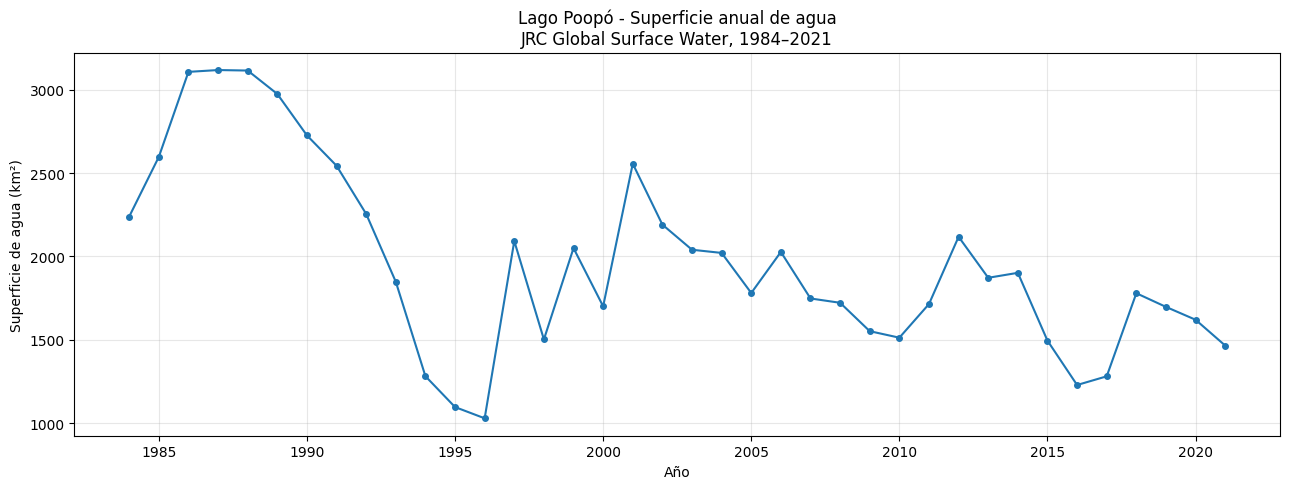

In [21]:
# ============================================================
# 7.8 Serie temporal de superficie total de agua
# ============================================================

plt.figure(figsize=(13, 5))

plt.plot(
    df_annual["year"],
    df_annual["total_km2"],
    marker="o",
    markersize=4
)

plt.xlabel("Año")
plt.ylabel("Superficie de agua (km²)")

plt.title(
    "Lago Poopó - Superficie anual de agua\n"
    "JRC Global Surface Water, 1984–2021"
)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

## Primera interpretación de la serie

Ahora hemos convertido aproximadamente cuatro décadas de observaciones
satelitales en una variable directamente interpretable:

**superficie anual de agua en km²**

Observa cuidadosamente la serie antes de continuar.

### Preguntas

1. ¿La superficie del Lago Poopó presenta una tendencia continua?

2. ¿O predominan fuertes fluctuaciones interanuales?

3. ¿Puedes identificar visualmente períodos de contracción?

4. ¿Puedes identificar períodos de recuperación?

5. ¿Qué ocurre alrededor de 1994?

6. ¿Qué ocurre alrededor de 2015–2016?

7. ¿Cuál parece ser visualmente el año con menor superficie de agua?

# 8. Agua permanente vs. agua estacional

La superficie total del lago proporciona información importante, pero no describe completamente su régimen hidrológico.

Dos lagos pueden tener la misma superficie total y presentar comportamientos muy diferentes.

Por esta razón separaremos:

### Agua permanente

Píxeles clasificados como agua permanente durante el año.

### Agua estacional

Píxeles donde el agua estuvo presente solamente durante parte del año.

Analizar ambas componentes permite estudiar cambios no solamente en la extensión del lago, sino también en su **persistencia temporal**.

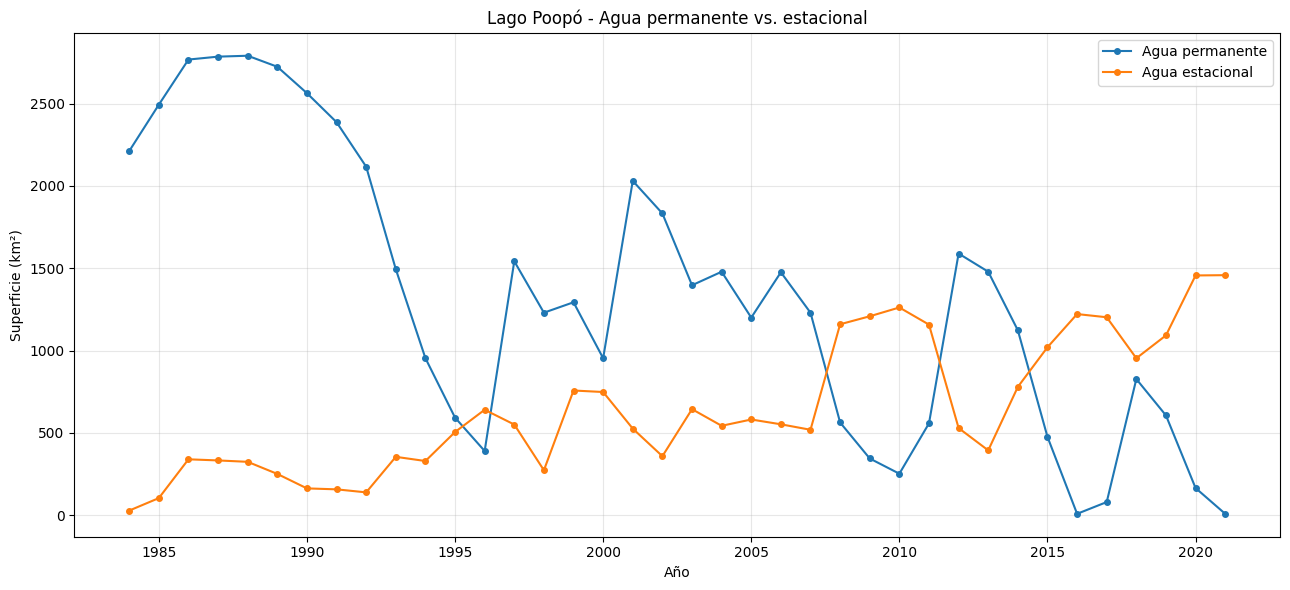

In [22]:
# ============================================================
# Agua permanente y agua estacional
# ============================================================

plt.figure(figsize=(13, 6))

plt.plot(
    df_annual["year"],
    df_annual["permanent_km2"],
    marker="o",
    markersize=4,
    label="Agua permanente"
)

plt.plot(
    df_annual["year"],
    df_annual["seasonal_km2"],
    marker="o",
    markersize=4,
    label="Agua estacional"
)

plt.xlabel("Año")
plt.ylabel("Superficie (km²)")

plt.title(
    "Lago Poopó - Agua permanente vs. estacional"
)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Preguntas

Observa ahora las dos componentes por separado.

1. ¿Cuál presenta mayor variabilidad?

2. ¿Existen años con gran superficie total pero poca agua permanente?

3. ¿Qué ocurre con el agua permanente durante los períodos de fuerte contracción?

4. ¿Qué información adicional obtenemos al separar agua permanente y estacional?

### Discusión

Considera la siguiente afirmación:

> "La extensión superficial de un lago no necesariamente describe su grado de permanencia."

¿Los datos del Lago Poopó apoyan esta afirmación?

# 9. Identificación de años extremos

Hasta ahora hemos inspeccionado visualmente las series.

Ahora utilizaremos Python para identificar automáticamente:

- máxima superficie;
- mínima superficie;
- mayor disminución interanual;
- mayor recuperación interanual.

## Nota metodológica

Aunque la serie comienza en 1984, ese año tiene observaciones solamente desde marzo.

Por esta razón conservaremos 1984 en las gráficas, pero excluiremos ese año del análisis automático de extremos.

In [23]:
# ============================================================
# Preparar datos para análisis de extremos
# ============================================================

df_extremes = (
    df_annual[
        df_annual["year"] >= 1985
    ]
    .copy()
    .reset_index(drop=True)
)

df_extremes["change_km2"] = (
    df_extremes["total_km2"]
    .diff()
)

previous_area = (
    df_extremes["total_km2"]
    .shift(1)
)

df_extremes["change_pct"] = np.where(
    previous_area > 0,
    100
    * df_extremes["change_km2"]
    / previous_area,
    np.nan
)

display(df_extremes.head())

,year,total_km2,seasonal_km2,permanent_km2,change_km2,change_pct
0,1985,2597.074571,103.132307,2493.942263,NaN,NaN
1,1986,3107.041701,338.871118,2768.170583,509.967131,19.636214
2,1987,3117.974860,332.089110,2785.885750,10.933159,0.351883
3,1988,3114.982334,323.603857,2791.378476,-2.992526,-0.095977
4,1989,2974.502777,250.093623,2724.409154,-140.479557,-4.509803


In [24]:
# ============================================================
# Identificar eventos extremos
# ============================================================

max_row = df_extremes.loc[
    df_extremes["total_km2"].idxmax()
]

min_row = df_extremes.loc[
    df_extremes["total_km2"].idxmin()
]

largest_loss = df_extremes.loc[
    df_extremes["change_km2"].idxmin()
]

largest_gain = df_extremes.loc[
    df_extremes["change_km2"].idxmax()
]


print("==========================================")
print("AÑO CON MAYOR SUPERFICIE")
print("==========================================")
print(
    f"Año: {int(max_row['year'])}"
)
print(
    f"Superficie: {max_row['total_km2']:.1f} km²"
)

print()

print("==========================================")
print("AÑO CON MENOR SUPERFICIE")
print("==========================================")
print(
    f"Año: {int(min_row['year'])}"
)
print(
    f"Superficie: {min_row['total_km2']:.1f} km²"
)

print()

print("==========================================")
print("MAYOR DISMINUCIÓN INTERANUAL")
print("==========================================")
print(
    f"Año: {int(largest_loss['year'])}"
)
print(
    f"Cambio: {largest_loss['change_km2']:.1f} km²"
)
print(
    f"Cambio relativo: {largest_loss['change_pct']:.1f} %"
)

print()

print("==========================================")
print("MAYOR RECUPERACIÓN INTERANUAL")
print("==========================================")
print(
    f"Año: {int(largest_gain['year'])}"
)
print(
    f"Cambio: +{largest_gain['change_km2']:.1f} km²"
)
print(
    f"Cambio relativo: +{largest_gain['change_pct']:.1f} %"
)

AÑO CON MAYOR SUPERFICIE
Año: 1987
Superficie: 3118.0 km²

AÑO CON MENOR SUPERFICIE
Año: 1996
Superficie: 1029.4 km²

MAYOR DISMINUCIÓN INTERANUAL
Año: 1998
Cambio: -590.4 km²
Cambio relativo: -28.2 %

MAYOR RECUPERACIÓN INTERANUAL
Año: 1997
Cambio: +1063.3 km²
Cambio relativo: +103.3 %


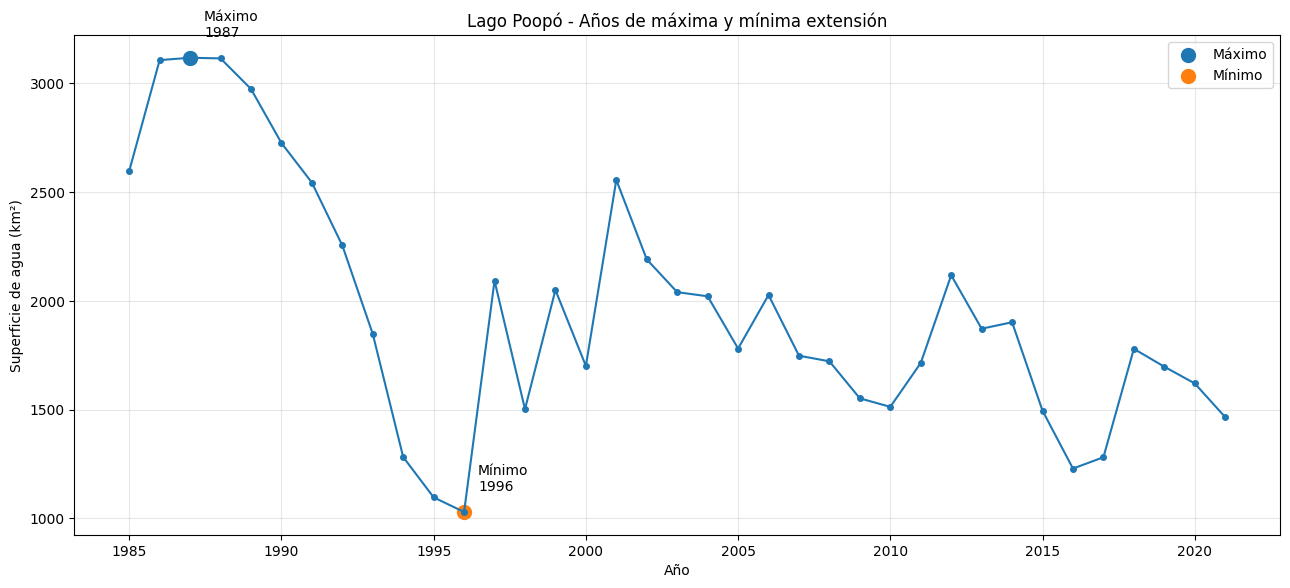

In [25]:
# ============================================================
# Visualizar máximos y mínimos
# ============================================================

plt.figure(figsize=(13, 6))

plt.plot(
    df_extremes["year"],
    df_extremes["total_km2"],
    marker="o",
    markersize=4
)

plt.scatter(
    max_row["year"],
    max_row["total_km2"],
    s=100,
    label="Máximo"
)

plt.scatter(
    min_row["year"],
    min_row["total_km2"],
    s=100,
    label="Mínimo"
)

plt.annotate(
    f"Máximo\n{int(max_row['year'])}",
    (
        max_row["year"],
        max_row["total_km2"]
    ),
    xytext=(10, 15),
    textcoords="offset points"
)

plt.annotate(
    f"Mínimo\n{int(min_row['year'])}",
    (
        min_row["year"],
        min_row["total_km2"]
    ),
    xytext=(10, 15),
    textcoords="offset points"
)

plt.xlabel("Año")
plt.ylabel("Superficie de agua (km²)")

plt.title(
    "Lago Poopó - Años de máxima y mínima extensión"
)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Interpretación

Compare los resultados automáticos con lo que había identificado visualmente.

### Preguntas

1. ¿Coincide el año mínimo con el que habías seleccionado visualmente?

2. ¿El año de mayor pérdida interanual coincide necesariamente con el año de menor superficie?

3. ¿Por qué son conceptos diferentes?

4. ¿Se observa recuperación inmediatamente después de los eventos de contracción?

5. ¿Los cambios parecen simétricos?

Es decir:

> ¿el lago pierde y recupera agua con velocidades similares?

# 10. ¿Dónde ocurrieron los cambios?

Hasta ahora hemos reducido el Lago Poopó a una serie temporal.

Esto es útil, pero hemos perdido una característica fundamental de los datos satelitales:

**la dimensión espacial.**

Ahora preguntaremos:

> ¿Dónde se concentraron las pérdidas y ganancias de agua?

Utilizaremos dos bandas:

### `transition`

Clasifica diferentes tipos de cambio de la superficie de agua.

### `change_abs`

Representa cambios en la frecuencia de ocurrencia entre dos períodos:

- 1984–1999;
- 2000–2021.

In [26]:
# ============================================================
# Mapa de transición
# ============================================================

transition = (
    gsw
    .select("transition")
    .updateMask(lake_domain)
    .clip(roi)
)

transition_palette = [
    "ffffff",  # 0 no change
    "0000ff",  # 1 permanent
    "22b14c",  # 2 new permanent
    "d1102d",  # 3 lost permanent
    "99d9ea",  # 4 seasonal
    "b5e61d",  # 5 new seasonal
    "e6a1aa",  # 6 lost seasonal
    "ff7f27",  # 7 seasonal -> permanent
    "ffc90e",  # 8 permanent -> seasonal
    "7f7f7f",  # 9 ephemeral permanent
    "c3c3c3"   # 10 ephemeral seasonal
]

vis_transition = {
    "min": 0,
    "max": 10,
    "palette": transition_palette
}

Map_transition = geemap.Map()

Map_transition.centerObject(roi, 9)
Map_transition.add_basemap("HYBRID")

Map_transition.addLayer(
    transition,
    vis_transition,
    "Transiciones"
)

Map_transition

Map(center=[-18.749925436709386, -66.99999999999993], controls=(WidgetControl(options=['position', 'transparen…

## Clases de transición

| Valor | Clase |
|---:|---|
| 0 | Sin cambio |
| 1 | Permanente |
| 2 | Nuevo permanente |
| 3 | Permanente perdido |
| 4 | Estacional |
| 5 | Nuevo estacional |
| 6 | Estacional perdido |
| 7 | Estacional → permanente |
| 8 | Permanente → estacional |
| 9 | Permanente efímero |
| 10 | Estacional efímero |

### Preguntas

1. ¿Dónde se concentran las pérdidas de agua?

2. ¿Están distribuidas uniformemente?

3. ¿Se observan zonas donde el agua estacional pasó a permanente?

4. ¿Existen sectores que cambiaron de permanente a estacional?

5. ¿Qué nos dice esto sobre la dinámica espacial del Lago Poopó?

In [27]:
# ============================================================
# Cambio absoluto en ocurrencia
# ============================================================

change_abs = (
    gsw
    .select("change_abs")
    .updateMask(lake_domain)
    .clip(roi)
)

vis_change = {
    "min": -100,
    "max": 100,
    "palette": [
        "d73027",
        "f7f7f7",
        "1a9850"
    ]
}

Map_change = geemap.Map()

Map_change.centerObject(roi, 9)
Map_change.add_basemap("HYBRID")

Map_change.addLayer(
    change_abs,
    vis_change,
    "Cambio en ocurrencia (%)"
)

Map_change

Map(center=[-18.749925436709386, -66.99999999999993], controls=(WidgetControl(options=['position', 'transparen…

### Interpretación

El mapa representa cambios en la frecuencia de ocurrencia del agua entre los dos períodos históricos utilizados por JRC.

De manera general:

- valores negativos indican pérdida o reducción de ocurrencia;
- valores cercanos a cero indican cambios menores;
- valores positivos indican aumento de ocurrencia.

### Pregunta

> ¿Dónde se observan las mayores reducciones en persistencia del agua?

Compara este resultado con el mapa de transición.

¿Ambos productos cuentan la misma historia?

# 11. Zoom temporal: 2013–2017

La serie anual permite identificar cambios importantes alrededor de 2015–2016.

Ahora aumentaremos la resolución temporal.

En lugar de utilizar una observación por año utilizaremos el producto:

`JRC/GSW1_4/MonthlyHistory`

Analizaremos:

**enero de 2013 – diciembre de 2017**

Esto permitirá estudiar cómo evolucionó el lago antes, durante y después del episodio de fuerte contracción.

---

## Una precaución importante

En el producto mensual:

| Clase | Significado |
|---:|---|
| 0 | Sin datos |
| 1 | No agua |
| 2 | Agua |

Por esta razón, una reducción aparente en superficie de agua podría estar influenciada por una baja disponibilidad de observaciones válidas.

Calcularemos simultáneamente:

1. superficie de agua;
2. porcentaje del dominio con datos válidos.

In [28]:
# ============================================================
# Cargar historia mensual
# ============================================================

monthly = ee.ImageCollection(
    "JRC/GSW1_4/MonthlyHistory"
)

print(
    "Número total de imágenes mensuales:",
    monthly.size().getInfo()
)

Número total de imágenes mensuales: 454


In [29]:
# ============================================================
# Área total del dominio histórico
# ============================================================

# Área de cada píxel en km²
pixel_area_km2 = ee.Image.pixelArea().divide(1e6)

# Calcular el área total del dominio histórico
domain_area_value = (
    pixel_area_km2
    .updateMask(lake_domain)
    .reduceRegion(
        reducer=ee.Reducer.sum(),
        geometry=roi,
        scale=30,
        maxPixels=1e10,
        tileScale=4
    )
    .get("area")
    .getInfo()
)

print(
    f"Área del dominio histórico: "
    f"{domain_area_value:.1f} km²"
)

Área del dominio histórico: 3130.7 km²


In [30]:
# ============================================================
# Preparar período mensual 2013–2017
# ============================================================

monthly_dates = pd.date_range(
    start="2013-01-01",
    end="2017-12-01",
    freq="MS"
)

print(
    "Número de meses:",
    len(monthly_dates)
)

print(
    "Primer mes:",
    monthly_dates[0].strftime("%Y-%m")
)

print(
    "Último mes:",
    monthly_dates[-1].strftime("%Y-%m")
)

Número de meses: 60
Primer mes: 2013-01
Último mes: 2017-12


In [31]:
# ============================================================
# Construir bandas mensuales de agua y cobertura válida
# ============================================================

monthly_stack = None

for date in monthly_dates:

    year = date.year
    month = date.month

    start_date = ee.Date.fromYMD(
        year,
        month,
        1
    )

    end_date = start_date.advance(
        1,
        "month"
    )

    # Seleccionar la imagen correspondiente al mes
    monthly_image = (
        ee.Image(
            monthly
            .filterDate(
                start_date,
                end_date
            )
            .first()
        )
        .select("water")
    )

    # --------------------------------------------
    # Superficie clasificada como agua
    # Clase 2 = agua
    # --------------------------------------------

    water_area = (
        pixel_area_km2
        .updateMask(
            monthly_image.eq(2)
        )
        .updateMask(
            lake_domain
        )
        .rename(
            f"water_{year}_{month:02d}"
        )
    )

    # --------------------------------------------
    # Superficie con observación válida
    # Clases 1 y 2
    # --------------------------------------------

    valid_area = (
        pixel_area_km2
        .updateMask(
            monthly_image.gt(0)
        )
        .updateMask(
            lake_domain
        )
        .rename(
            f"valid_{year}_{month:02d}"
        )
    )

    month_image = ee.Image.cat([
        water_area,
        valid_area
    ])

    if monthly_stack is None:
        monthly_stack = month_image
    else:
        monthly_stack = monthly_stack.addBands(
            month_image
        )


print("Imagen mensual multibanda preparada.")

Imagen mensual multibanda preparada.


In [32]:
# ============================================================
# Verificar número de bandas
# ============================================================

n_monthly_bands = (
    monthly_stack
    .bandNames()
    .size()
    .getInfo()
)

print(
    "Número de bandas:",
    n_monthly_bands
)

print(
    "Número esperado:",
    len(monthly_dates) * 2
)

Número de bandas: 120
Número esperado: 120


In [33]:
# ============================================================
# Calcular superficie mensual y cobertura válida
# ============================================================

monthly_values = (
    monthly_stack
    .reduceRegion(
        reducer=ee.Reducer.sum(),
        geometry=roi,
        scale=30,
        maxPixels=1e10,
        tileScale=4
    )
    .getInfo()
)

print("Cálculo mensual terminado.")

print(
    "Número de valores:",
    len(monthly_values)
)

Cálculo mensual terminado.
Número de valores: 120


In [34]:
# ============================================================
# Organizar resultados mensuales en Pandas
# ============================================================

monthly_records = []

for date in monthly_dates:

    year = date.year
    month = date.month

    water = monthly_values.get(
        f"water_{year}_{month:02d}",
        0
    )

    valid = monthly_values.get(
        f"valid_{year}_{month:02d}",
        0
    )

    water = 0 if water is None else water
    valid = 0 if valid is None else valid

    valid_pct = (
        valid / domain_area_value
    ) * 100

    monthly_records.append({
        "date": date,
        "year": year,
        "month": month,
        "water_km2": water,
        "valid_km2": valid,
        "valid_pct": valid_pct
    })


df_monthly = pd.DataFrame(
    monthly_records
)

display(df_monthly.head())

print("...")

display(df_monthly.tail())

,date,year,month,water_km2,valid_km2,valid_pct
0,2013-01-01,2013,1,0.000000,0.000000,0.000000
1,2013-02-01,2013,2,1242.273436,1410.361391,45.048754
2,2013-03-01,2013,3,1750.757241,2749.154948,87.811539
3,2013-04-01,2013,4,1835.180397,2990.428745,95.518134
4,2013-05-01,2013,5,1777.495732,2626.302178,83.887464


...


,date,year,month,water_km2,valid_km2,valid_pct
55,2017-08-01,2017,8,333.574637,1752.355209,55.972475
56,2017-09-01,2017,9,248.989610,3014.048249,96.272571
57,2017-10-01,2017,10,91.649403,2939.620866,93.895265
58,2017-11-01,2017,11,5.942644,3130.716605,99.999108
59,2017-12-01,2017,12,420.538807,3126.845265,99.875453


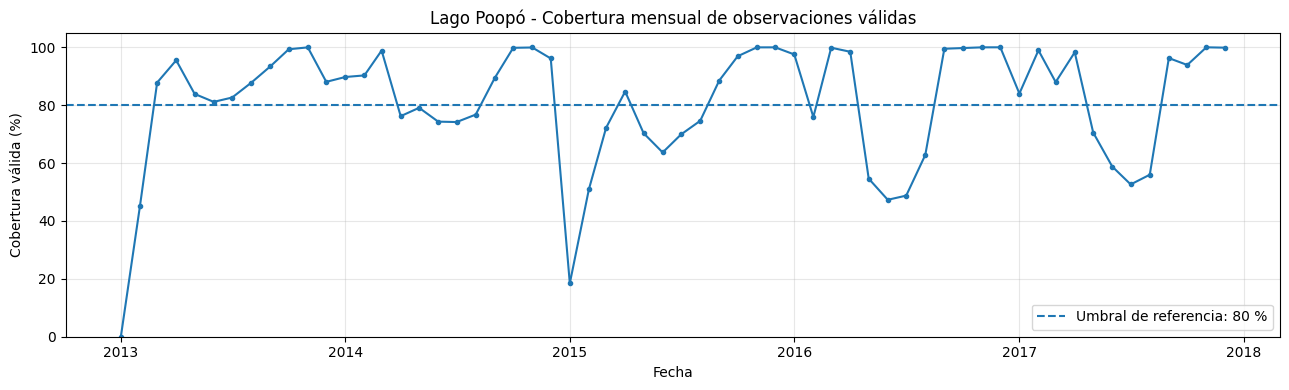

In [35]:
# ============================================================
# Cobertura mensual de observaciones válidas
# ============================================================

plt.figure(figsize=(13, 4))

plt.plot(
    df_monthly["date"],
    df_monthly["valid_pct"],
    marker="o",
    markersize=3
)

plt.axhline(
    80,
    linestyle="--",
    label="Umbral de referencia: 80 %"
)

plt.xlabel("Fecha")
plt.ylabel("Cobertura válida (%)")

plt.title(
    "Lago Poopó - Cobertura mensual "
    "de observaciones válidas"
)

plt.ylim(0, 105)

plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

## Control de calidad de la serie mensual

Una característica importante del producto mensual es que no todos los
píxeles necesariamente contienen una observación válida en cada mes.

La clase:

- `0` representa ausencia de datos;
- `1` representa una observación clasificada como no agua;
- `2` representa una observación clasificada como agua.

Por esta razón, antes de interpretar una reducción en la superficie de agua
debemos comprobar que exista suficiente cobertura de observaciones.

Para este ejercicio utilizaremos de manera exploratoria un umbral de:

**80 % de cobertura válida**

Este valor no corresponde a un umbral oficial del producto JRC. Se utiliza solamente como criterio de control de calidad para el ejercicio.

In [36]:
# ============================================================
# Aplicar filtro de cobertura válida
# ============================================================

MIN_VALID_COVERAGE = 80

df_monthly["water_km2_filtered"] = (
    df_monthly["water_km2"]
    .where(
        df_monthly["valid_pct"]
        >= MIN_VALID_COVERAGE
    )
)

print(
    "Meses totales:",
    len(df_monthly)
)

print(
    "Meses con cobertura >= 80 %:",
    df_monthly[
        "water_km2_filtered"
    ].notna().sum()
)

Meses totales: 60
Meses con cobertura >= 80 %: 37


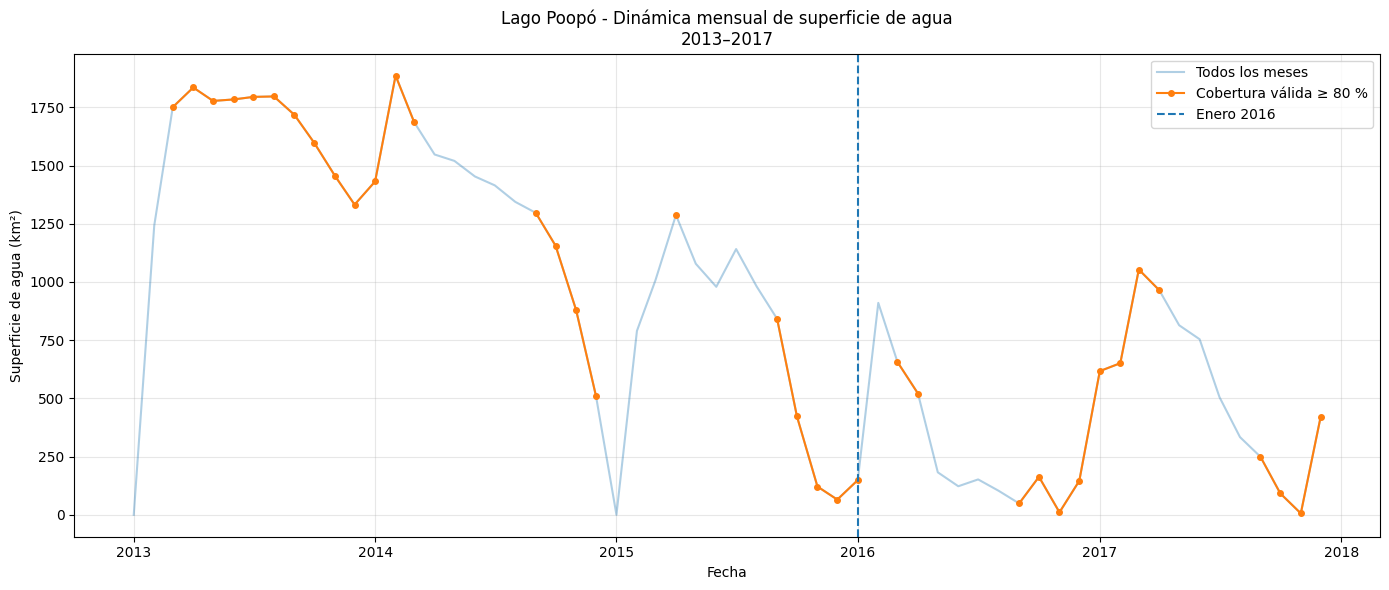

In [37]:
# ============================================================
# Serie mensual de superficie de agua
# ============================================================

plt.figure(figsize=(14, 6))

# Todos los meses
plt.plot(
    df_monthly["date"],
    df_monthly["water_km2"],
    alpha=0.35,
    label="Todos los meses"
)

# Meses con cobertura >= 80 %
plt.plot(
    df_monthly["date"],
    df_monthly["water_km2_filtered"],
    marker="o",
    markersize=4,
    label="Cobertura válida ≥ 80 %"
)

# Referencia temporal
plt.axvline(
    pd.Timestamp("2016-01-01"),
    linestyle="--",
    label="Enero 2016"
)

plt.xlabel("Fecha")
plt.ylabel("Superficie de agua (km²)")

plt.title(
    "Lago Poopó - Dinámica mensual de superficie de agua\n"
    "2013–2017"
)

plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

In [38]:
# ============================================================
# Identificar el mínimo mensual
# con cobertura válida >= 80 %
# ============================================================

reliable_months = (
    df_monthly[
        df_monthly["valid_pct"]
        >= MIN_VALID_COVERAGE
    ]
    .copy()
)

minimum_month = reliable_months.loc[
    reliable_months[
        "water_km2"
    ].idxmin()
]

print(
    "Mes con menor superficie de agua"
)

print(
    "Fecha:",
    minimum_month["date"]
    .strftime("%Y-%m")
)

print(
    f"Superficie de agua: "
    f"{minimum_month['water_km2']:.1f} km²"
)

print(
    f"Cobertura válida: "
    f"{minimum_month['valid_pct']:.1f} %"
)

Mes con menor superficie de agua
Fecha: 2017-11
Superficie de agua: 5.9 km²
Cobertura válida: 100.0 %


### Preguntas

Observa cuidadosamente la serie mensual.

1. ¿La contracción del lago ocurrió de forma gradual o abrupta?

2. ¿En qué momento comienza a observarse una reducción importante?

3. ¿Cuál es el mes con menor superficie entre aquellos con suficiente
   cobertura de observaciones?

4. ¿Se observa recuperación durante 2016 y 2017?

5. ¿La recuperación alcanza inmediatamente los niveles observados en 2013?

6. ¿Qué información adicional proporciona la resolución mensual que no era
   visible en la serie anual?

7. ¿Por qué es importante analizar la cobertura válida antes de interpretar
   un mínimo de superficie de agua?

## Comparación espacial: abril 2013 vs. enero 2016

NASA Earth Observatory utilizó imágenes Landsat de abril de 2013 y enero de 2016 para ilustrar la fuerte contracción del Lago Poopó.

Utilizaremos esos mismos meses con el producto JRC para realizar una comparación espacial.

In [39]:
# ============================================================
# Función para obtener una imagen mensual
# ============================================================

def get_monthly_image(year, month):

    return ee.Image(
        monthly
        .filter(
            ee.Filter.eq("year", year)
        )
        .filter(
            ee.Filter.eq("month", month)
        )
        .first()
    )

In [40]:
# ============================================================
# Comparar abril 2013 y enero 2016
# ============================================================

apr_2013 = get_monthly_image(
    2013,
    4
)

jan_2016 = get_monthly_image(
    2016,
    1
)


water_2013 = (
    apr_2013
    .select("water")
    .eq(2)
    .selfMask()
    .clip(roi)
)

water_2016 = (
    jan_2016
    .select("water")
    .eq(2)
    .selfMask()
    .clip(roi)
)


Map_event = geemap.Map()

Map_event.centerObject(roi, 9)
Map_event.add_basemap("HYBRID")

Map_event.addLayer(
    water_2013,
    {"palette": ["0000ff"]},
    "Abril 2013",
    True
)

Map_event.addLayer(
    water_2016,
    {"palette": ["00ffff"]},
    "Enero 2016",
    False
)

Map_event

Map(center=[-18.749925436709326, -67.00000000000044], controls=(WidgetControl(options=['position', 'transparen…

### Explora el mapa

Activa y desactiva las capas:

- Abril 2013
- Enero 2016

### Pregunta

> ¿La reducción ocurrió uniformemente en toda la superficie del lago?

Identifica visualmente qué sectores parecen haber sido más afectados.

Ahora relaciona este resultado con:

- occurrence;
- recurrence;
- transition;
- change_abs.

¿Existe coherencia entre los diferentes productos?

# 12. Interpretación de resultados

Hasta este punto hemos utilizado diferentes productos satelitales para reconstruir la dinámica del Lago Poopó desde distintas perspectivas.

Ahora integraremos los resultados.

## Pregunta 1 — Persistencia espacial

¿Qué sectores del Lago Poopó presentan mayor persistencia histórica de agua?

Utiliza como evidencia:

- occurrence;
- seasonality;
- recurrence.

---

## Pregunta 2 — Variabilidad temporal

¿Cómo describirías la dinámica del lago entre 1984 y 2021?

¿Predomina:

- una tendencia gradual;
- una alta variabilidad interanual;
- eventos extremos;
- una combinación de estos comportamientos?

---

## Pregunta 3 — Agua permanente

¿Qué ocurre con el agua permanente durante los principales eventos de contracción?

¿La disminución afecta primero:

- el agua estacional;
- el agua permanente;
- ambas simultáneamente?

---

## Pregunta 4 — Eventos extremos

¿Coinciden los años de:

- menor superficie;
- mayor pérdida interanual?

¿Por qué no necesariamente deberían coincidir?

---

## Pregunta 5 — Dimensión espacial

¿Dónde se concentran las mayores pérdidas de persistencia?

¿Los cambios afectan de la misma manera todas las zonas históricamente inundadas?

---

## Pregunta 6 — Escala temporal

¿Qué información adicional proporcionó la serie mensual 2013–2012017 respecto a la serie anual?

---

## Pregunta 7 — Causalidad

Los datos satelitales muestran claramente cambios importantes en la superficie del lago.

Pero:

> ¿Podemos determinar sus causas solamente a partir de estos mapas?

¿Qué información adicional necesitaríamos para investigar los mecanismos responsables?